In [14]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import collect_set, size, col, expr, array_except
from pyspark.sql.functions import explode, rand
from pyspark.sql.functions import sum as spark_sum
from pyspark.ml.fpm import FPGrowth

In [15]:
# 1️⃣ Start Spark
# --------------------------------------------------

spark = SparkSession.builder \
    .appName("MarketBasketEvaluation") \
    .getOrCreate()

In [16]:
# 2️⃣ Load Dataset
# --------------------------------------------------

df = spark.read.csv(
    "full_file.csv",
    header=True,
    inferSchema=True
).select("order_id", "product_name")

In [17]:
# 3️⃣ Train/Test Split (Leakage Safe)
# --------------------------------------------------

orders = df.select("order_id").distinct()

train_orders, test_orders = orders.randomSplit([0.8, 0.2], seed=42)

train_df = df.join(train_orders, "order_id")
test_df = df.join(test_orders, "order_id")

In [18]:
# 4️⃣ Create Transactions
# --------------------------------------------------

train_transactions = train_df.groupBy("order_id") \
    .agg(collect_set("product_name").alias("items"))

test_transactions = test_df.groupBy("order_id") \
    .agg(collect_set("product_name").alias("items"))

In [19]:
# 5️⃣ Train FP-Growth Model
# --------------------------------------------------

fp = FPGrowth(
    itemsCol="items",
    minSupport=0.005,
    minConfidence=0.35
)

model = fp.fit(train_transactions)

print("Top Association Rules")
model.associationRules.orderBy("confidence", ascending=False).show(10, False)

Top Association Rules
+--------------------+----------+------------------+------------------+--------------------+
|antecedent          |consequent|confidence        |lift              |support             |
+--------------------+----------+------------------+------------------+--------------------+
|[Organic Fuji Apple]|[Banana]  |0.3733206564424786|2.5444583411332222|0.010259783489144352|
|[Honeycrisp Apple]  |[Banana]  |0.3575757575757576|2.4371451277860254|0.0089817127964982  |
+--------------------+----------+------------------+------------------+--------------------+



In [20]:
# 6️⃣ Hide-One-Item Evaluation
# --------------------------------------------------

# explode items
exploded = test_transactions.select(
    "order_id",
    explode("items").alias("hidden_item"),
    "items"
)

# randomly choose one item per basket
hidden_items = exploded.withColumn(
    "rand", rand()
).groupBy("order_id").agg(
    expr("min_by(hidden_item, rand)").alias("hidden_item"),
    expr("first(items)").alias("items")
)

# create input basket (remove hidden item)
test_input = hidden_items.withColumn(
    "input_items",
    array_except(col("items"), expr("array(hidden_item)"))
)

In [21]:
# 7️⃣ Generate Predictions
# --------------------------------------------------

prediction_input = test_input.select(
    col("order_id"),
    col("input_items").alias("items"),
    col("hidden_item")
)

predictions = model.transform(prediction_input)

In [22]:
# 8️⃣ Check if hidden item is recommended
# --------------------------------------------------

evaluation = predictions.withColumn(
    "hit",
    expr("array_contains(prediction, hidden_item)")
)


In [23]:
metrics = evaluation.select(
    spark_sum(expr("case when hit then 1 else 0 end")).alias("hits"),
    spark_sum(size("prediction")).alias("total_predictions"),
    expr("count(*)").alias("total_baskets")
)

values = metrics.collect()[0]

hits = values["hits"]
total_predictions = values["total_predictions"]
total_baskets = values["total_baskets"]

hit_rate = hits / total_baskets if total_baskets > 0 else 0
precision = hits / total_predictions if total_predictions > 0 else 0
recall = hits / total_baskets if total_baskets > 0 else 0

print("------------ Evaluation ------------")
print("Total Baskets:", total_baskets)
print("Hits:", hits)
print("Hit Rate:", hit_rate)
print("Precision:", precision)
print("Recall:", recall)

------------ Evaluation ------------
Total Baskets: 220237
Hits: 334
Hit Rate: 0.001516548082293166
Precision: 0.04880187025131502
Recall: 0.001516548082293166


In [24]:
from pyspark.sql import functions as F

avg_items_per_order = (
    df.groupBy("order_id")
      .agg(F.count("product_name").alias("items_per_order"))
      .agg(F.avg("items_per_order").alias("avg_items_per_order"))
)

avg_value = avg_items_per_order.first()["avg_items_per_order"]
print(avg_value)

10.139386820093375


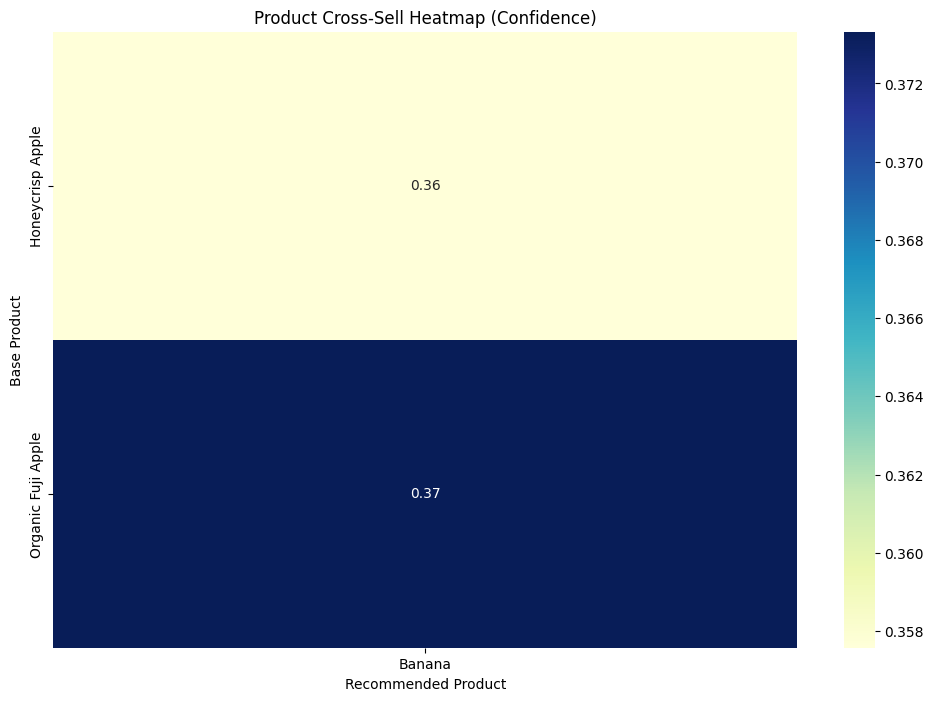

In [25]:
# -------- Product Cross-Sell Heatmap --------

import seaborn as sns
import matplotlib.pyplot as plt

# Get association rules from FP-Growth model
rules = model.associationRules

# Explode arrays so each rule becomes a row
rules_heatmap = rules.selectExpr(
    "explode(antecedent) as product_A",
    "explode(consequent) as product_B",
    "confidence"
)

# Take top rules to keep visualization readable
top_rules = rules_heatmap.orderBy("confidence", ascending=False).limit(30)

# Convert small result to pandas for plotting
heatmap_df = top_rules.toPandas()

# Create matrix for heatmap
heatmap_matrix = heatmap_df.pivot(
    index="product_A",
    columns="product_B",
    values="confidence"
)

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_matrix, annot=True, cmap="YlGnBu")
plt.title("Product Cross-Sell Heatmap (Confidence)")
plt.xlabel("Recommended Product")
plt.ylabel("Base Product")
plt.show()

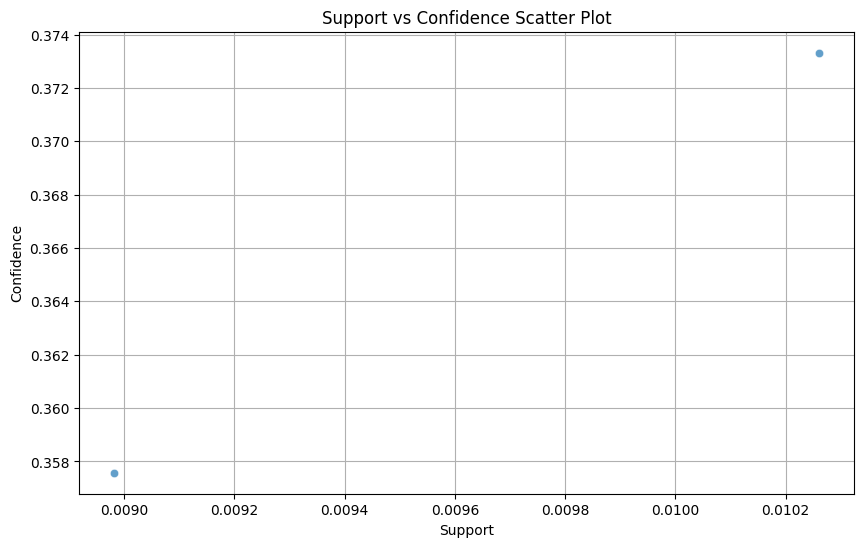

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get association rules from FP-Growth model
rules_df = model.associationRules.select("support", "confidence").toPandas()

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules_df, x="support", y="confidence", alpha=0.7)
plt.title("Support vs Confidence Scatter Plot")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.grid(True)
plt.show()

In [28]:
spark.stop()